In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.layers import Conv2D, Dense, MaxPool2D, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

In [7]:
# dowload cifar 10, it's already built in
(x_train, y_train), (x_val, y_val) = tf.keras.datasets.cifar10.load_data()

In [8]:
columns = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

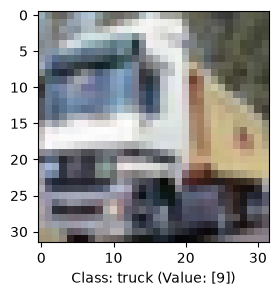

In [9]:
def plot_sample(x, y, index):
    flattening = y[index][0]
    show = f"Class: {columns[flattening]} (Value: {y[index]})"
    plt.figure(figsize=(10,3))
    plt.imshow(x[index])
    plt.xlabel(show)
plot_sample(x_train, y_train, 1)

In [22]:
y_train.shape

(50000,)

In [20]:
# i need it to be 2d
y_train= y_train.reshape(-1,)

In [12]:
x_train.shape

(50000, 32, 32, 3)

In [13]:
# now we make x in a float form
x_train = x_train.astype(float)/255.0
x_val = x_val.astype(float)/255.0

In [38]:
cnn = models.Sequential([
    layers.RandomFlip('Horizontal'), #augmentation -> variety without new data
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape =(32,32,3)),
    MaxPool2D(pool_size=(2,2)),
    Conv2D(64, (3,3),activation='relu'),
    MaxPool2D((2,2)),
    Conv2D(128, (3,3),activation='relu'),
    MaxPool2D((2,2)),
    Flatten(),
     Dense(128, activation='relu'),
     Dropout(0.5), #regulation
     Dense(10, activation='softmax')
])

In [33]:
cnn.compile(optimizer='Adam',
            loss = 'sparse_categorical_crossentropy',
            metrics = ['Accuracy'])

In [34]:
loss_curve = cnn.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - Accuracy: 0.3743 - loss: 1.6927 - val_Accuracy: 0.4900 - val_loss: 1.4149
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - Accuracy: 0.5316 - loss: 1.3138 - val_Accuracy: 0.5904 - val_loss: 1.1411
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - Accuracy: 0.5899 - loss: 1.1585 - val_Accuracy: 0.6159 - val_loss: 1.0892
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - Accuracy: 0.6275 - loss: 1.0520 - val_Accuracy: 0.6486 - val_loss: 0.9835
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - Accuracy: 0.6631 - loss: 0.9680 - val_Accuracy: 0.6712 - val_loss: 0.9416
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - Accuracy: 0.6838 - loss: 0.9041 - val_Accuracy: 0.6837 - val_loss: 0.9020
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - Accuracy: 0.7077 - loss: 0.8428 - val_Accuracy: 0.6872 - val_loss: 0.9144
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - Accuracy: 0.7236 -

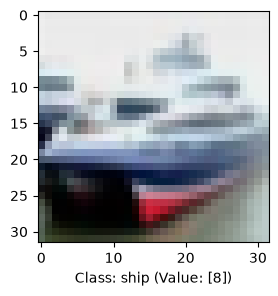

In [35]:
plot_sample(x_val, y_val, 1)

In [36]:
predict = cnn.predict(x_val)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [37]:
predict[:5]

array([[4.15910326e-04, 8.85059344e-05, 1.10838003e-03, 8.83649349e-01,
        1.39352574e-04, 6.37386963e-02, 5.79106342e-03, 1.38155039e-04,
        4.45644855e-02, 3.66033171e-04],
       [3.76825599e-04, 2.95259636e-02, 1.66499881e-08, 4.71883936e-08,
        9.50500234e-10, 5.13097464e-12, 5.63826985e-09, 3.01525444e-10,
        9.69316363e-01, 7.80833478e-04],
       [1.04046710e-01, 3.32519889e-01, 1.67903223e-03, 2.62589916e-03,
        5.37480169e-04, 8.67913332e-05, 7.17496849e-04, 7.09911576e-04,
        4.97145116e-01, 5.99316284e-02],
       [6.60099864e-01, 1.34044895e-02, 2.09269742e-03, 1.58607247e-04,
        3.78685351e-03, 3.94096514e-06, 7.80186838e-06, 2.00114751e-04,
        3.18885088e-01, 1.36055902e-03],
       [8.53810125e-05, 7.18999081e-06, 5.20440489e-02, 2.08978262e-03,
        8.30414295e-01, 3.37028614e-04, 1.14989959e-01, 1.89531529e-05,
        1.17671907e-05, 1.58673254e-06]], dtype=float32)